<a href="https://colab.research.google.com/github/ajsarsva/video-captioning-thesis/blob/main/notebooks/day17_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Master setup cell

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

if os.path.exists('/content/video-captioning-thesis'):
    %cd /content/video-captioning-thesis
    !git pull origin main
else:
    !git clone https://github.com/ajsarsva/video-captioning-thesis.git
    %cd /content/video-captioning-thesis

import sys
sys.path.append('/content/video-captioning-thesis/src')

print("✅ Ready!")

Mounted at /content/drive
Cloning into 'video-captioning-thesis'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 96 (delta 50), reused 27 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 16.87 MiB | 13.25 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/video-captioning-thesis
✅ Ready!


In [2]:
!pip install pycocoevalcap pycocotools -q
!pip install nltk -q

import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ Evaluation libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 5.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Evaluation libraries ready!


Bringing result files from drive to here

In [3]:
import json, os
import sys
sys.path.append('/content/video-captioning-thesis/src')

# Load ground truth annotations
with open('/content/drive/MyDrive/thesis-data/MSR_VTT.json') as f:
    gt_data = json.load(f)

# Load all three strategy captions
with open('/content/drive/MyDrive/thesis-data/captions/strategy_A_full.json') as f:
    results_a = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_B_full.json') as f:
    results_b = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_C_full.json') as f:
    results_c = json.load(f)

print(f"Ground truth videos: {len(gt_data['images'])}")
print(f"Strategy A captions: {len(results_a)}")
print(f"Strategy B captions: {len(results_b)}")
print(f"Strategy C captions: {len(results_c)}")

Ground truth videos: 10000
Strategy A captions: 7010
Strategy B captions: 7010
Strategy C captions: 7010


Build Ground Truth and Hypothesis Dictionaries

In [4]:
# Build ground truth dictionary
# Format: {video_id: [ref1, ref2, ... ref20]}
ground_truth = {}
for ann in gt_data['annotations']:
    vid = ann['image_id']
    if vid not in ground_truth:
        ground_truth[vid] = []
    ground_truth[vid].append(ann['caption'])

print(f"Ground truth built for {len(ground_truth)} videos")
print(f"Sample — video0 has {len(ground_truth['video0'])} reference captions")

# Build hypothesis dictionaries
# Format: {video_id: [generated_caption]}
def build_hypothesis(results):
    hyp = {}
    for vid, val in results.items():
        if val['caption'].strip():  # skip empty captions
            hyp[vid] = [val['caption']]
    return hyp

hyp_a = build_hypothesis(results_a)
hyp_b = build_hypothesis(results_b)
hyp_c = build_hypothesis(results_c)

print(f"\nHypothesis A: {len(hyp_a)} videos")
print(f"Hypothesis B: {len(hyp_b)} videos")
print(f"Hypothesis C: {len(hyp_c)} videos")

Ground truth built for 10000 videos
Sample — video0 has 20 reference captions

Hypothesis A: 7010 videos
Hypothesis B: 7010 videos
Hypothesis C: 7010 videos


Evaluation Function

In [5]:
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def evaluate(ground_truth, hypothesis, strategy_name):
    """
    Evaluate captions against ground truth using standard metrics.
    Only evaluates videos present in both ground truth and hypothesis.
    """
    print(f"\nEvaluating {strategy_name}...")

    # Find common video IDs
    common_ids = set(ground_truth.keys()) & set(hypothesis.keys())
    print(f"  Evaluating on {len(common_ids)} videos")

    # Filter to common IDs
    gt_filtered = {vid: ground_truth[vid] for vid in common_ids}
    hyp_filtered = {vid: hypothesis[vid] for vid in common_ids}

    scores = {}

    # BLEU
    bleu_scorer = Bleu(4)
    bleu_scores, _ = bleu_scorer.compute_score(gt_filtered, hyp_filtered)
    scores['BLEU-1'] = round(bleu_scores[0] * 100, 2)
    scores['BLEU-4'] = round(bleu_scores[3] * 100, 2)

    # METEOR
    meteor_scorer = Meteor()
    meteor_score, _ = meteor_scorer.compute_score(gt_filtered, hyp_filtered)
    scores['METEOR'] = round(meteor_score * 100, 2)

    # ROUGE-L
    rouge_scorer = Rouge()
    rouge_score, _ = rouge_scorer.compute_score(gt_filtered, hyp_filtered)
    scores['ROUGE-L'] = round(rouge_score * 100, 2)

    # CIDEr
    cider_scorer = Cider()
    cider_score, _ = cider_scorer.compute_score(gt_filtered, hyp_filtered)
    scores['CIDEr'] = round(cider_score * 100, 2)

    # Print results
    print(f"  BLEU-1:  {scores['BLEU-1']}")
    print(f"  BLEU-4:  {scores['BLEU-4']}")
    print(f"  METEOR:  {scores['METEOR']}")
    print(f"  ROUGE-L: {scores['ROUGE-L']}")
    print(f"  CIDEr:   {scores['CIDEr']}")

    return scores

Run Evaluation on All Three

In [6]:
scores_a = evaluate(ground_truth, hyp_a, "Strategy A (Uniform)")
scores_b = evaluate(ground_truth, hyp_b, "Strategy B (SSIM)")
scores_c = evaluate(ground_truth, hyp_c, "Strategy C (CLIP)")


Evaluating Strategy A (Uniform)...
  Evaluating on 7010 videos
{'testlen': 67826, 'reflen': 64702, 'guess': [67826, 60816, 53806, 46804], 'correct': [43668, 19971, 7393, 2652]}
ratio: 1.0482828969738023
  BLEU-1:  64.38
  BLEU-4:  20.14
  METEOR:  21.1
  ROUGE-L: 46.85
  CIDEr:   28.07

Evaluating Strategy B (SSIM)...
  Evaluating on 7010 videos
{'testlen': 66691, 'reflen': 63900, 'guess': [66691, 59681, 52672, 45670], 'correct': [41808, 18492, 6648, 2310]}
ratio: 1.0436776212832388
  BLEU-1:  62.69
  BLEU-4:  18.77
  METEOR:  20.01
  ROUGE-L: 45.76
  CIDEr:   24.81

Evaluating Strategy C (CLIP)...
  Evaluating on 7010 videos
{'testlen': 68025, 'reflen': 64890, 'guess': [68025, 61015, 54006, 47006], 'correct': [43401, 19610, 7205, 2547]}
ratio: 1.048312528895037
  BLEU-1:  63.8
  BLEU-4:  19.62
  METEOR:  20.76
  ROUGE-L: 46.5
  CIDEr:   26.74


Print Main Results Table

In [7]:
print("\n")
print("=" * 65)
print("MAIN RESULTS TABLE")
print("=" * 65)
print(f"{'Strategy':<25} {'BLEU-1':>8} {'BLEU-4':>8} {'METEOR':>8} {'ROUGE-L':>8} {'CIDEr':>8}")
print("-" * 65)
print(f"{'A — Uniform (K=8)':<25} {scores_a['BLEU-1']:>8} {scores_a['BLEU-4']:>8} {scores_a['METEOR']:>8} {scores_a['ROUGE-L']:>8} {scores_a['CIDEr']:>8}")
print(f"{'B — SSIM (θ=0.7)':<25} {scores_b['BLEU-1']:>8} {scores_b['BLEU-4']:>8} {scores_b['METEOR']:>8} {scores_b['ROUGE-L']:>8} {scores_b['CIDEr']:>8}")
print(f"{'C — CLIP K-Means (K=8)':<25} {scores_c['BLEU-1']:>8} {scores_c['BLEU-4']:>8} {scores_c['METEOR']:>8} {scores_c['ROUGE-L']:>8} {scores_c['CIDEr']:>8}")
print("=" * 65)



MAIN RESULTS TABLE
Strategy                    BLEU-1   BLEU-4   METEOR  ROUGE-L    CIDEr
-----------------------------------------------------------------
A — Uniform (K=8)            64.38    20.14     21.1    46.85    28.07
B — SSIM (θ=0.7)             62.69    18.77    20.01    45.76    24.81
C — CLIP K-Means (K=8)        63.8    19.62    20.76     46.5    26.74


Saving Results to Drive

In [8]:
all_scores = {
    'Strategy_A': scores_a,
    'Strategy_B': scores_b,
    'Strategy_C': scores_c
}

# Save as JSON
with open('/content/drive/MyDrive/thesis-data/results/evaluation_scores.json', 'w') as f:
    json.dump(all_scores, f, indent=2)

# Save as CSV for easy viewing
import csv
csv_path = '/content/drive/MyDrive/thesis-data/results/scores.csv'

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Strategy', 'BLEU-1', 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr'])
    writer.writerow(['A - Uniform', scores_a['BLEU-1'], scores_a['BLEU-4'], scores_a['METEOR'], scores_a['ROUGE-L'], scores_a['CIDEr']])
    writer.writerow(['B - SSIM', scores_b['BLEU-1'], scores_b['BLEU-4'], scores_b['METEOR'], scores_b['ROUGE-L'], scores_b['CIDEr']])
    writer.writerow(['C - CLIP', scores_c['BLEU-1'], scores_c['BLEU-4'], scores_c['METEOR'], scores_c['ROUGE-L'], scores_c['CIDEr']])

print("Results saved to Drive!")
print(f"  - evaluation_scores.json")
print(f"  - scores.csv")

Results saved to Drive!
  - evaluation_scores.json
  - scores.csv


Plot Results Bar Chart

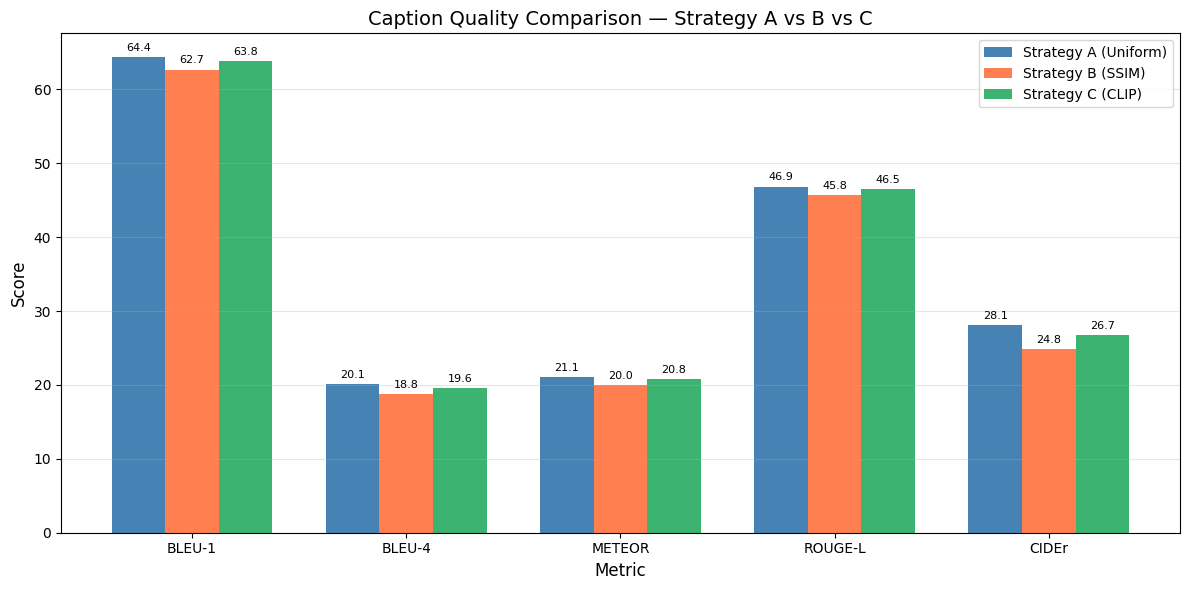

Chart saved to Drive!


In [9]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['BLEU-1', 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars_a = ax.bar(x - width, [scores_a[m] for m in metrics], width,
                label='Strategy A (Uniform)', color='steelblue')
bars_b = ax.bar(x, [scores_b[m] for m in metrics], width,
                label='Strategy B (SSIM)', color='coral')
bars_c = ax.bar(x + width, [scores_c[m] for m in metrics], width,
                label='Strategy C (CLIP)', color='mediumseagreen')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Caption Quality Comparison — Strategy A vs B vs C', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in [bars_a, bars_b, bars_c]:
    for rect in bar:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                   xy=(rect.get_x() + rect.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points",
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis-data/figures/evaluation_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive!")

Speed vs Quality Table

In [12]:
print("=" * 75)
print("SPEED vs QUALITY TRADEOFF TABLE")
print("=" * 75)
print(f"{'Strategy':<25} {'Avg Time/Video':>15} {'Total Time':>12} {'CIDEr':>8} {'METEOR':>8}")
print("-" * 75)

strategies = ['Strategy_A', 'Strategy_B', 'Strategy_C']
labels = ['A — Uniform (K=8)', 'B — SSIM (θ=0.7)', 'C — CLIP K-Means (K=8)']

for strategy, label in zip(strategies, labels):
    t = timing[strategy]
    s = scores[strategy]
    print(f"{label:<25} {str(t['avg_time_per_video_seconds'])+'s':>15} {str(t['total_time_minutes'])+'min':>12} {s['CIDEr']:>8} {s['METEOR']:>8}")

print("=" * 75)

# Compute relative differences vs Strategy A
a_time = timing['Strategy_A']['avg_time_per_video_seconds']
a_cider = scores['Strategy_A']['CIDEr']

print("\nRelative to Strategy A:")
for strategy, label in zip(strategies[1:], labels[1:]):
    t = timing[strategy]['avg_time_per_video_seconds']
    c = scores[strategy]['CIDEr']
    time_overhead = ((t - a_time) / a_time) * 100
    cider_diff = c - a_cider
    print(f"{label}: +{time_overhead:.1f}% slower, {cider_diff:.2f} CIDEr difference")

SPEED vs QUALITY TRADEOFF TABLE
Strategy                   Avg Time/Video   Total Time    CIDEr   METEOR
---------------------------------------------------------------------------
A — Uniform (K=8)                  1.803s    210.66min    28.07     21.1
B — SSIM (θ=0.7)                   2.065s    241.29min    24.81    20.01
C — CLIP K-Means (K=8)             2.153s    251.59min    26.74    20.76

Relative to Strategy A:
B — SSIM (θ=0.7): +14.5% slower, -3.26 CIDEr difference
C — CLIP K-Means (K=8): +19.4% slower, -1.33 CIDEr difference


Speed vs Quality Plot

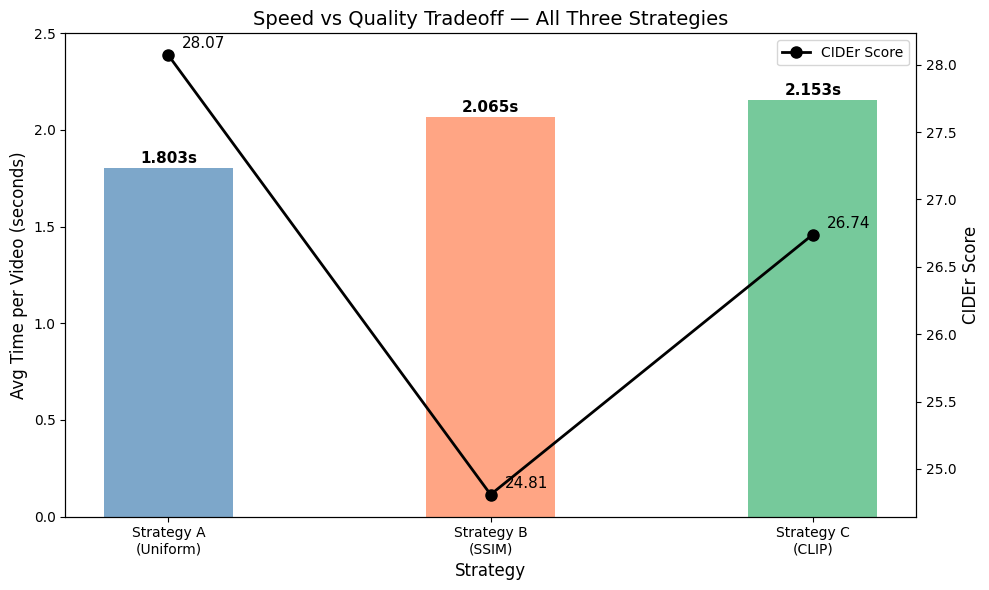

Speed vs quality plot saved to Drive!


In [19]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(3)
strategy_labels = ['Strategy A\n(Uniform)', 'Strategy B\n(SSIM)', 'Strategy C\n(CLIP)']
times = [timing[s]['avg_time_per_video_seconds'] for s in strategies]
ciders = [scores[s]['CIDEr'] for s in strategies]
colors = ['steelblue', 'coral', 'mediumseagreen']

# Bar chart for time
bars = ax1.bar(x, times, color=colors, alpha=0.7, width=0.4)
ax1.set_xlabel('Strategy', fontsize=12)
ax1.set_ylabel('Avg Time per Video (seconds)', fontsize=12, color='black')
ax1.set_xticks(x)
ax1.set_xticklabels(strategy_labels)

# Add time labels on bars
for bar, t in zip(bars, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{t:.3f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Line chart for CIDEr on second y-axis
ax2 = ax1.twinx()
ax2.plot(x, ciders, 'ko-', linewidth=2, markersize=8, label='CIDEr Score')
ax2.set_ylabel('CIDEr Score', fontsize=12, color='black')

# Add CIDEr labels
for i, (xi, c) in enumerate(zip(x, ciders)):
    ax2.annotate(f'{c:.2f}', xy=(xi, c), xytext=(10, 5),
                textcoords='offset points', fontsize=11, color='black')

ax1.set_title('Speed vs Quality Tradeoff — All Three Strategies', fontsize=14)
ax2.legend(loc='upper right')
ax1.set_ylim(0, 2.5)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis-data/figures/speed_vs_quality.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Speed vs quality plot saved to Drive!")

Efficiency Score — One Final Metric

In [14]:
# Compute efficiency score = CIDEr / time (higher is better)
print("\nEFFICIENCY SCORE (CIDEr per second — higher is better)")
print("=" * 45)
for strategy, label in zip(strategies, labels):
    t = timing[strategy]['avg_time_per_video_seconds']
    c = scores[strategy]['CIDEr']
    efficiency = c / t
    print(f"{label:<25} {efficiency:.3f}")
print("=" * 45)
print("Strategy A has highest efficiency — best CIDEr per unit of compute time")


EFFICIENCY SCORE (CIDEr per second — higher is better)
A — Uniform (K=8)         15.568
B — SSIM (θ=0.7)          12.015
C — CLIP K-Means (K=8)    12.420
Strategy A has highest efficiency — best CIDEr per unit of compute time


In [20]:
# Save ablation results
ablation_results = {
    'speed_quality_tradeoff': {
        'Strategy_A': {'avg_time_sec': 1.803, 'CIDEr': 28.07,
                       'METEOR': 21.1, 'efficiency': 15.568},
        'Strategy_B': {'avg_time_sec': 2.065, 'CIDEr': 24.81,
                       'METEOR': 20.01, 'efficiency': 12.015},
        'Strategy_C': {'avg_time_sec': 2.153, 'CIDEr': 26.74,
                       'METEOR': 20.76, 'efficiency': 12.420}
    },
    'relative_to_A': {
        'B_time_overhead_percent': 14.5,
        'B_cider_difference': -3.26,
        'C_time_overhead_percent': 19.4,
        'C_cider_difference': -1.33
    }
}

import json
with open('/content/drive/MyDrive/thesis-data/results/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print("Ablation results saved to Drive!")

Ablation results saved to Drive!
